In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch

/opt/anaconda3/lib/python3.12/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/lib/python3.12/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <367D4265-B20F-34BD-94EB-4F3EE47C385B> /opt/anaconda3/lib/python3.12/site-packages/torchvision/image.so
  Reason: tried: '/opt/anaconda3/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/lib/python3.12/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
DATA_DIR = "./dataset for project"

all_image_paths = {}
for subfolder in sorted(glob.glob(os.path.join(DATA_DIR, "images_0*"))):
    img_folder = os.path.join(subfolder, "images")
    for img_file in os.listdir(img_folder):
        all_image_paths[img_file] = os.path.join(img_folder, img_file)

print(f"Total images found: {len(all_image_paths)}")  # should be ~112,120

df = pd.read_csv(os.path.join(DATA_DIR, "Data_Entry_2017.csv"))
print("CSV shape:", df.shape)
df.head()

Total images found: 112120
CSV shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [3]:
# Split pipe-separated labels into lists, e.g. "Atelectasis|Effusion" -> ["Atelectasis","Effusion"]
df['labels_list'] = df['Finding Labels'].str.split('|')

# One-hot encode all 14 diseases
mlb = MultiLabelBinarizer()
label_matrix = mlb.fit_transform(df['labels_list'])

label_cols = mlb.classes_.tolist()
print("Disease classes:", label_cols)
print("Label matrix shape:", label_matrix.shape)  # (112120, 15) — includes "No Finding"

# Add label columns back to dataframe
label_df = pd.DataFrame(label_matrix, columns=label_cols)
df = pd.concat([df.reset_index(drop=True), label_df], axis=1)

df[['Image Index', 'Finding Labels'] + label_cols].head(10)

Disease classes: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Label matrix shape: (112120, 15)


,Image Index,Finding Labels,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,Cardiomegaly,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,00000003_000.png,Hernia,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
5,00000003_001.png,Hernia,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
6,00000003_002.png,Hernia,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
7,00000003_003.png,Hernia|Infiltration,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
8,00000003_004.png,Hernia,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
9,00000003_005.png,Hernia,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'Infiltration'),
  Text(1, 0, 'Effusion'),
  Text(2, 0, 'Atelectasis'),
  Text(3, 0, 'Nodule'),
  Text(4, 0, 'Mass'),
  Text(5, 0, 'Pneumothorax'),
  Text(6, 0, 'Consolidation'),
  Text(7, 0, 'Pleural_Thickening'),
  Text(8, 0, 'Cardiomegaly'),
  Text(9, 0, 'Emphysema'),
  Text(10, 0, 'Edema'),
  Text(11, 0, 'Fibrosis'),
  Text(12, 0, 'Pneumonia'),
  Text(13, 0, 'Hernia')])

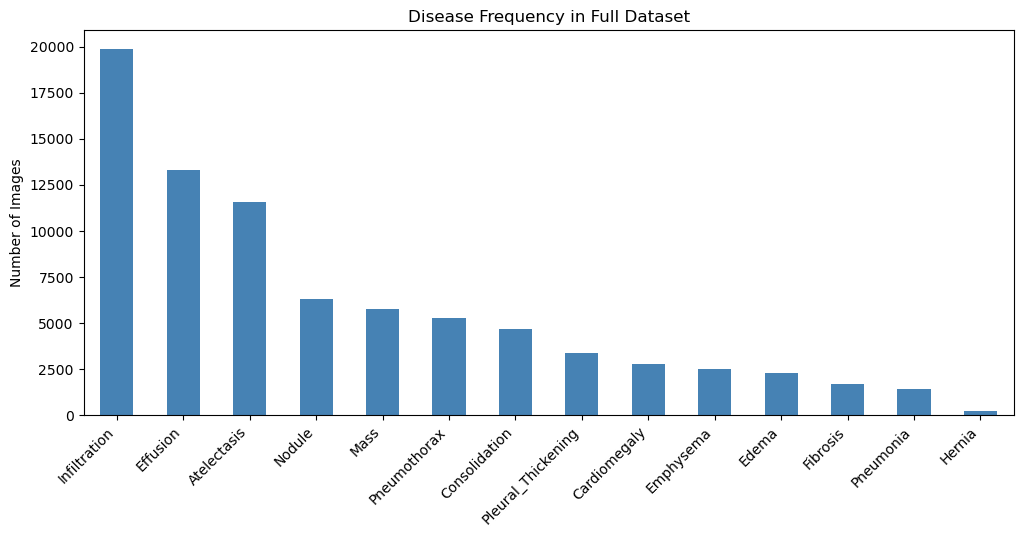

In [4]:
DISEASE_COLS = [c for c in label_cols if c != 'No Finding']

disease_counts = df[DISEASE_COLS].sum().sort_values(ascending=False)
disease_counts.plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.title("Disease Frequency in Full Dataset")
plt.ylabel("Number of Images"); plt.xticks(rotation=45, ha='right')

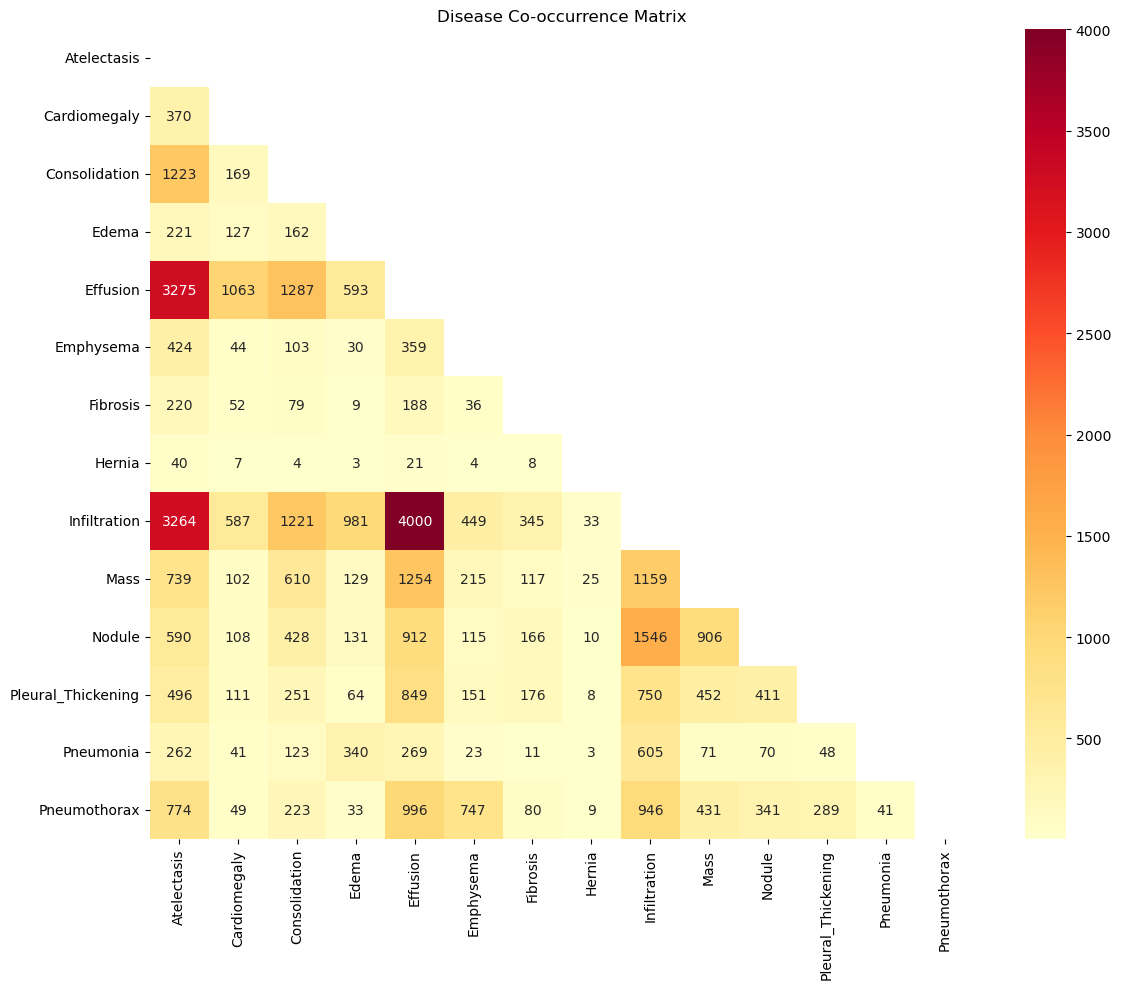

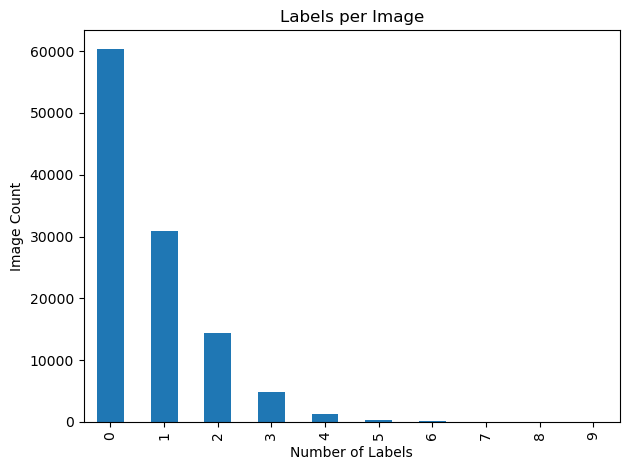

In [5]:
co_matrix = df[DISEASE_COLS].T.dot(df[DISEASE_COLS])
arr = co_matrix.to_numpy(copy=True).astype(int)
np.fill_diagonal(arr, 0)
co_matrix = pd.DataFrame(arr, index=co_matrix.index, columns=co_matrix.columns)

mask = np.triu(np.ones_like(arr, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', mask=mask)
plt.title("Disease Co-occurrence Matrix")
plt.tight_layout()
plt.show()

df['label_count'] = df[DISEASE_COLS].sum(axis=1)
df['label_count'].value_counts().sort_index().plot(kind='bar')
plt.title("Labels per Image")
plt.xlabel("Number of Labels")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

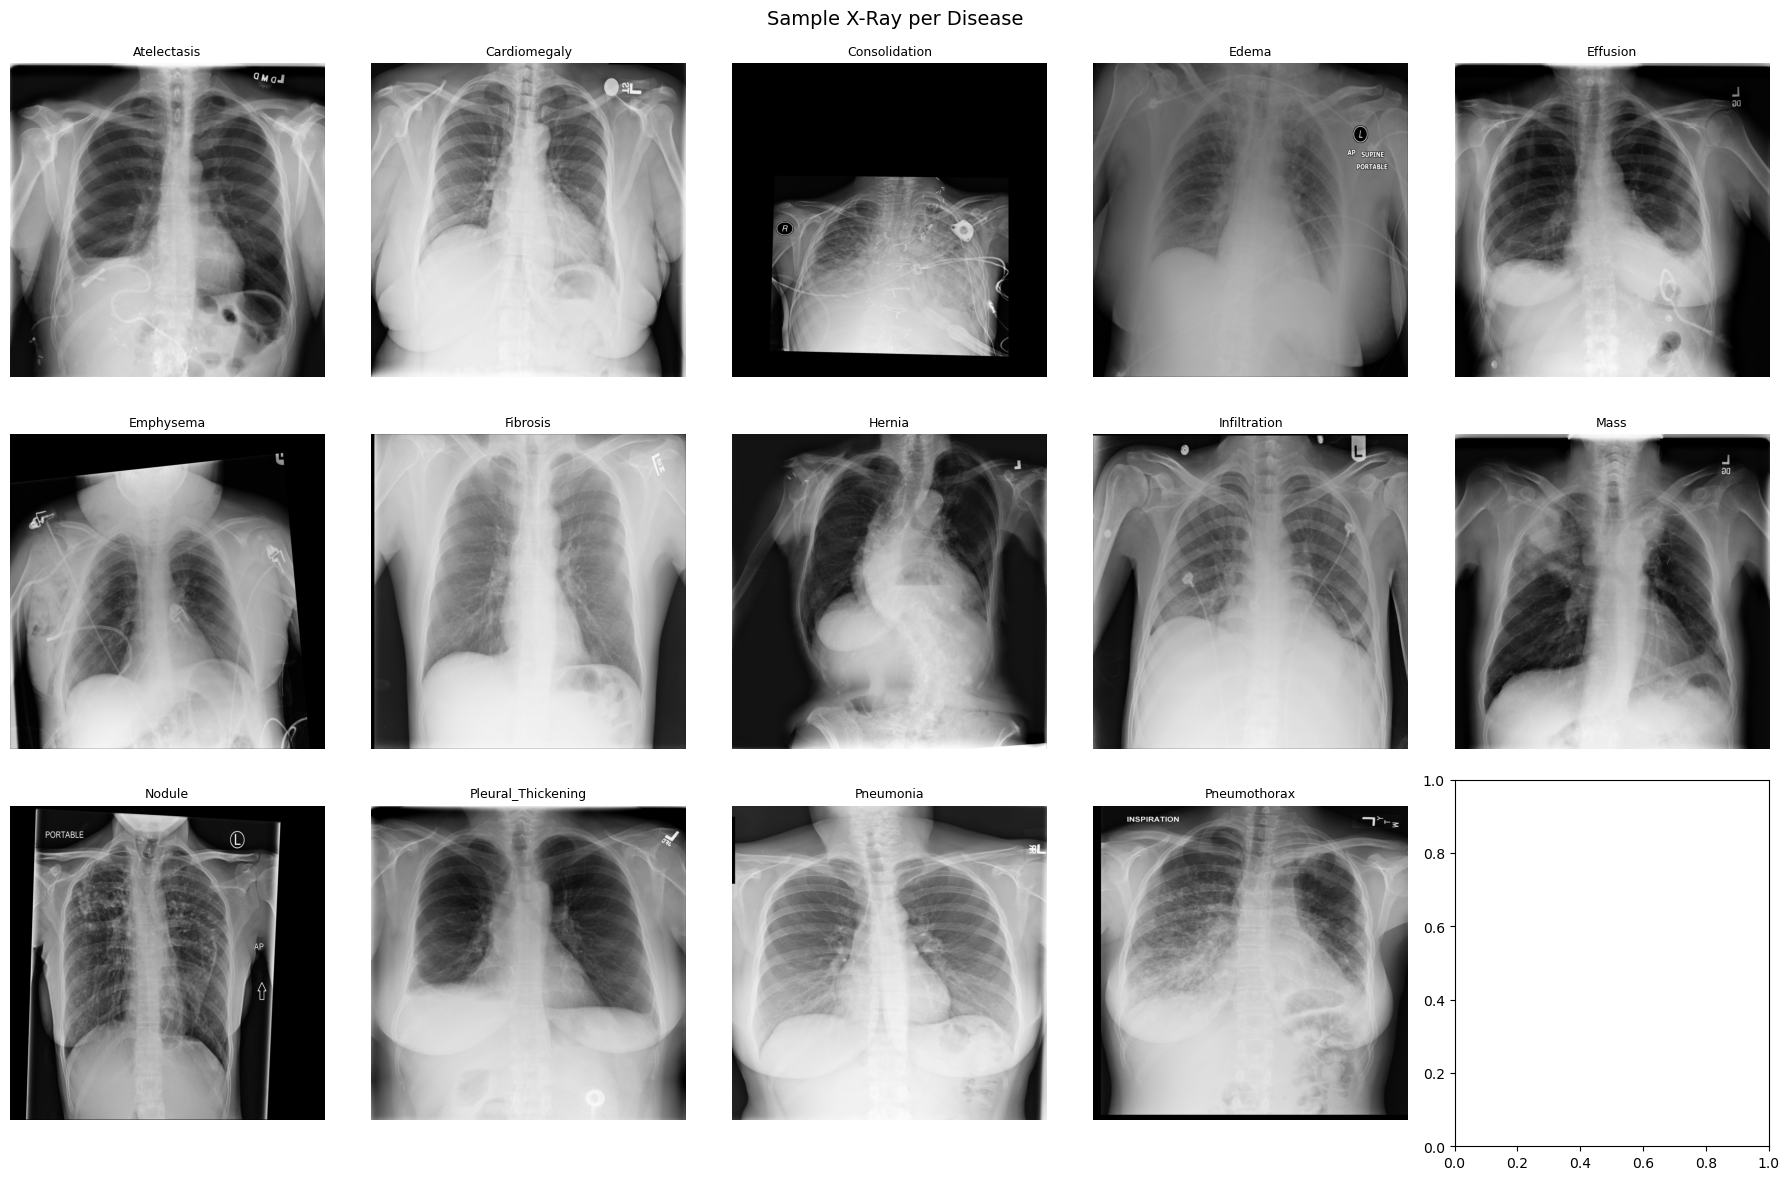

In [6]:
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
for ax, disease in zip(axes.flat, DISEASE_COLS):
    sample = df[df[disease] == 1].sample(1, random_state=42).iloc[0]
    img = Image.open(all_image_paths[sample['Image Index']]).convert('L')
    ax.imshow(img, cmap='gray'); ax.set_title(disease, fontsize=9); ax.axis('off')
plt.suptitle("Sample X-Ray per Disease", fontsize=14)
plt.tight_layout(); plt.show()

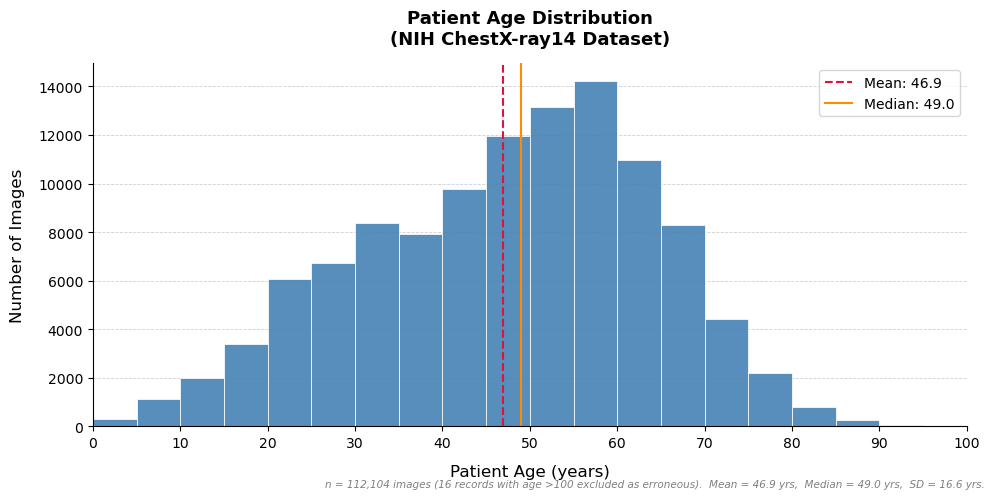

In [7]:
# Filter out erroneous age entries (16 rows with age > 100, up to 414 — data entry errors)
df_age = df[df['Patient Age'] <= 100].copy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_age['Patient Age'], bins=range(0, 101, 5), color='steelblue',
        edgecolor='white', linewidth=0.6, alpha=0.9)

mean_age   = df_age['Patient Age'].mean()
median_age = df_age['Patient Age'].median()

ax.axvline(mean_age,   color='crimson',    linestyle='--', linewidth=1.5, label=f'Mean: {mean_age:.1f}')
ax.axvline(median_age, color='darkorange', linestyle='-',  linewidth=1.5, label=f'Median: {median_age:.1f}')

ax.set_xlabel("Patient Age (years)", fontsize=12, labelpad=10)
ax.set_ylabel("Number of Images",    fontsize=12, labelpad=10)
ax.set_title("Patient Age Distribution\n(NIH ChestX-ray14 Dataset)",
             fontsize=13, fontweight='bold', pad=14)

ax.set_xlim(0, 100)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=10)
sns.despine(ax=ax)

fig.text(0.99, 0.01,
         f"n = {len(df_age):,} images (16 records with age >100 excluded as erroneous).  "
         f"Mean = {mean_age:.1f} yrs,  Median = {median_age:.1f} yrs,  SD = {df_age['Patient Age'].std():.1f} yrs.",
         ha='right', va='bottom', fontsize=7.5, color='gray', style='italic')

plt.tight_layout()
plt.savefig("age_distribution.pdf", dpi=300, bbox_inches='tight')
plt.savefig("age_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

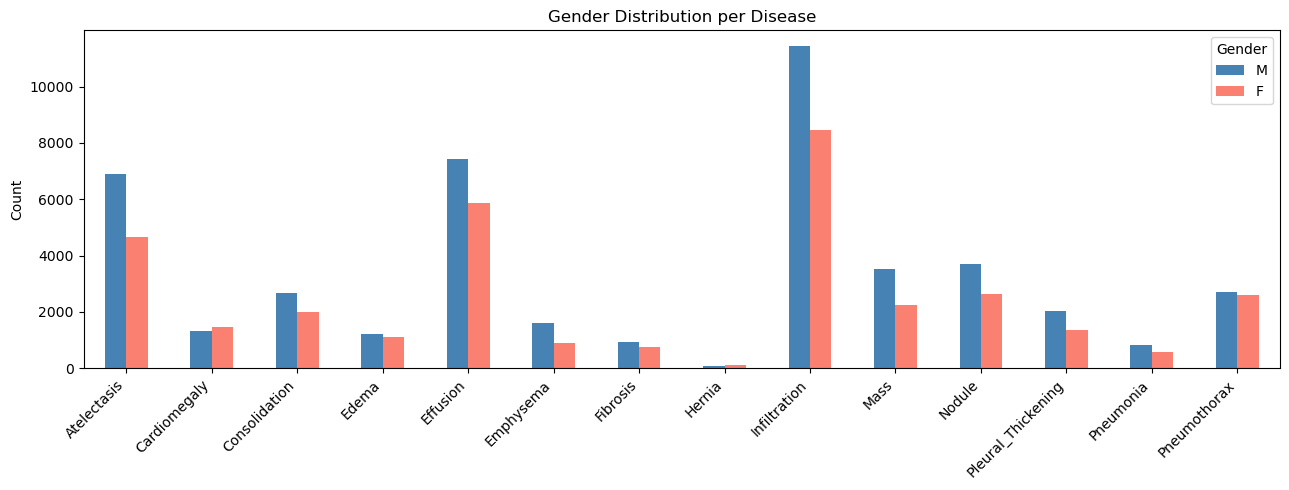

In [8]:
gender_counts = {}
for d in DISEASE_COLS:
    sub = df[df[d] == 1]
    gender_counts[d] = sub['Patient Gender'].value_counts().to_dict()
gender_df = pd.DataFrame(gender_counts).T.fillna(0)
gender_df.plot(kind='bar', figsize=(13, 5), color=['steelblue', 'salmon'])
plt.title("Gender Distribution per Disease")
plt.xticks(rotation=45, ha='right'); plt.ylabel("Count")
plt.legend(title="Gender"); plt.tight_layout(); plt.show()

In [9]:
# Use the official NIH split files (prevents data leakage across patients)
with open(os.path.join(DATA_DIR, "train_val_list.txt")) as f:
    train_val_files = set(f.read().splitlines())

with open(os.path.join(DATA_DIR, "test_list.txt")) as f:
    test_files = set(f.read().splitlines())

df_trainval = df[df['Image Index'].isin(train_val_files)].reset_index(drop=True)
df_test     = df[df['Image Index'].isin(test_files)].reset_index(drop=True)

# Split train_val into train (90%) and val (10%), keeping patients together
unique_patients = df_trainval['Patient ID'].unique()
train_patients, val_patients = train_test_split(unique_patients, test_size=0.1, random_state=42)

df_train = df_trainval[df_trainval['Patient ID'].isin(train_patients)].reset_index(drop=True)
df_val   = df_trainval[df_trainval['Patient ID'].isin(val_patients)].reset_index(drop=True)

print(f"Train samples : {len(df_train)}")
print(f"Val   samples : {len(df_val)}")
print(f"Test  samples : {len(df_test)}")

# Sanity check — no patient overlap
train_ids = set(df_train['Patient ID'])
val_ids   = set(df_val['Patient ID'])
test_ids  = set(df_test['Patient ID'])
assert len(train_ids & val_ids) == 0,  "OVERLAP between train and val!"
assert len(train_ids & test_ids) == 0, "OVERLAP between train and test!"
print("\nNo patient overlap — splits are clean.")

Train samples : 77988
Val   samples : 8536
Test  samples : 25596

No patient overlap — splits are clean.


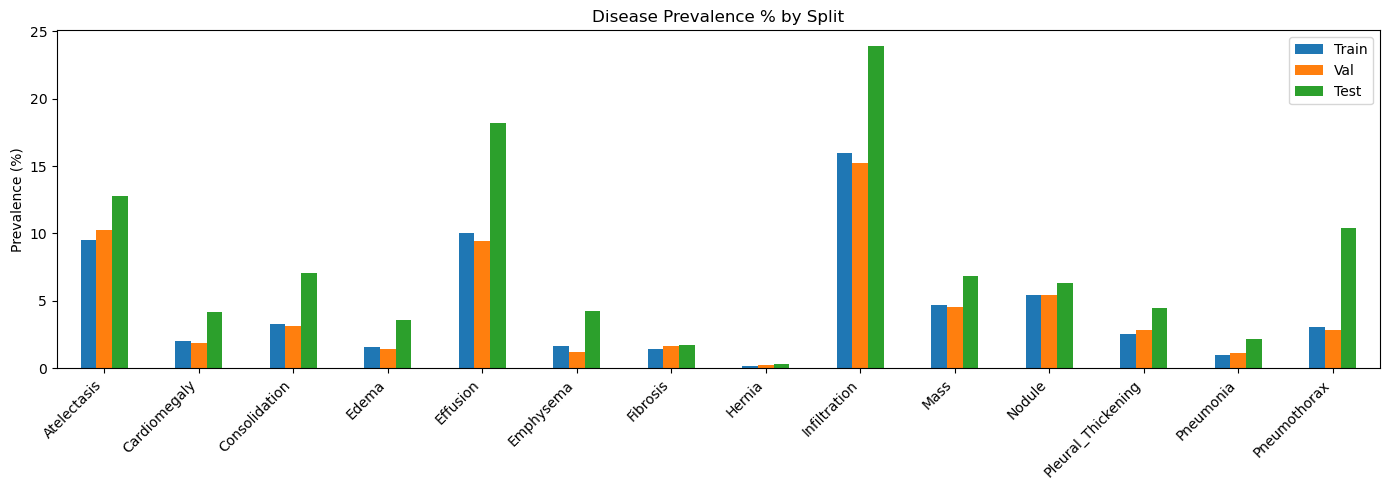

In [10]:
splits = {'Train': df_train, 'Val': df_val, 'Test': df_test}
prev = pd.DataFrame({k: v[DISEASE_COLS].mean() * 100 for k, v in splits.items()})
prev.plot(kind='bar', figsize=(14, 5))
plt.title("Disease Prevalence % by Split")
plt.ylabel("Prevalence (%)"); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

In [11]:
# Count positives and negatives per class (excluding "No Finding")
pos_counts = df_train[DISEASE_COLS].sum()
neg_counts = len(df_train) - pos_counts
pos_weight = (neg_counts / pos_counts).values  # shape: (14,)

print("Class weights (higher = rarer disease):")
for name, w in sorted(zip(DISEASE_COLS, pos_weight), key=lambda x: -x[1]):
    print(f"  {name:<25} {w:.1f}x")

Class weights (higher = rarer disease):
  Hernia                    638.2x
  Pneumonia                 98.7x
  Fibrosis                  69.2x
  Edema                     61.2x
  Emphysema                 58.2x
  Cardiomegaly              49.3x
  Pleural_Thickening        38.1x
  Pneumothorax              31.6x
  Consolidation             29.2x
  Mass                      20.4x
  Nodule                    17.4x
  Atelectasis               9.5x
  Effusion                  8.9x
  Infiltration              5.2x


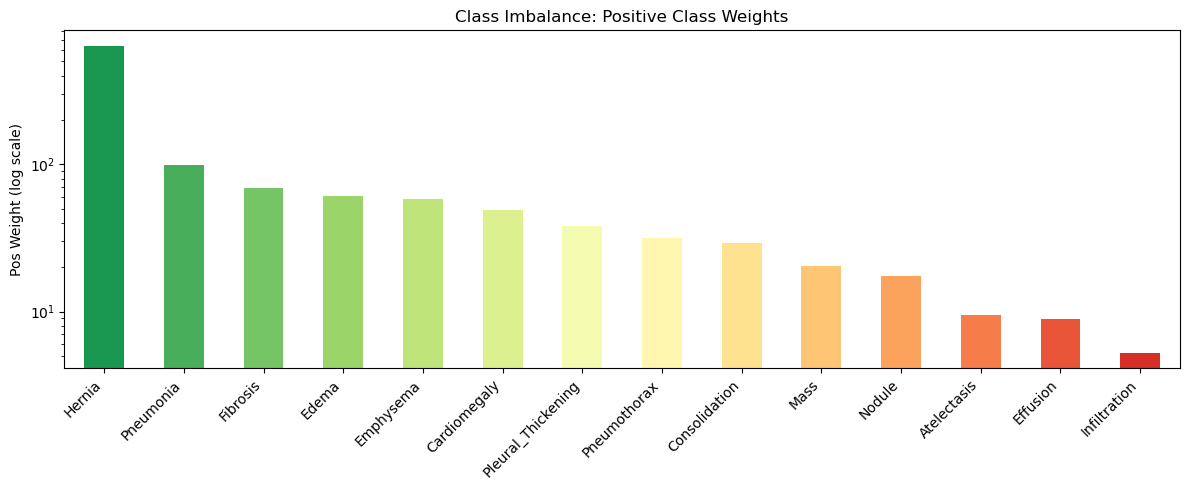

In [12]:
weights = pd.Series(pos_weight, index=DISEASE_COLS).sort_values(ascending=False)
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(weights)))
weights.plot(kind='bar', color=colors, figsize=(12, 5))
plt.yscale('log'); plt.ylabel("Pos Weight (log scale)")
plt.title("Class Imbalance: Positive Class Weights")
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

In [13]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_path_dict, label_cols, transform=None):
        self.df              = dataframe
        self.image_path_dict = image_path_dict
        self.label_cols      = label_cols
        self.transform       = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = self.image_path_dict[row['Image Index']]  # lookup from dict
        image    = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(row[self.label_cols].values.astype(np.float32))
        return image, labels

In [14]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = ChestXrayDataset(df_train, all_image_paths, DISEASE_COLS, transform=train_transform)
val_dataset   = ChestXrayDataset(df_val,   all_image_paths, DISEASE_COLS, transform=val_test_transform)
test_dataset  = ChestXrayDataset(df_test,  all_image_paths, DISEASE_COLS, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

print(f"Batches — Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Batches — Train: 2438, Val: 267, Test: 800


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32, 14])


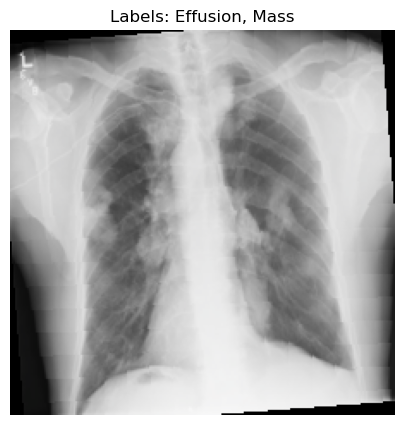

In [15]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

# Find first image in batch that has at least one disease
idx = 0
for i in range(len(labels)):
    if labels[i].sum() > 0:
        idx = i
        break

img = images[idx].permute(1, 2, 0).numpy()
img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img = np.clip(img, 0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
diseases_present = [DISEASE_COLS[i] for i, v in enumerate(labels[idx]) if v == 1]
plt.title("Labels: " + (", ".join(diseases_present) if diseases_present else "No Finding"))
plt.axis('off')
plt.show()